In [1]:
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

from hcc_multimodal.baselines.transforms import (
    CLINICAL_X_COLUMNS,
    DataType,
    build_preprocessor,
)
from hcc_multimodal.baselines.evaluation import (
    RANDOM_STATE,
    run_cv_experiment,
    plot_cv_results,
)
from hcc_multimodal.baselines.config import PARAM_GRIDS


In [2]:
ROOT = Path().resolve().parents[1]


data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

In [3]:
data.head()

,SID,UCH_ID_lesion,UCH_ID_liver,Age,Weight,Height,Sex,Ethnic Group,Race,"If Other Race, Specify",...,RFS_central,RFS_central_event,vascular_invasion,vascular_invasion_label,resection_score,grading,grade_label,well_grade,moderate_grade,poor_grade
0,1.0,H034,NaN,67.7,NaN,NaN,2.0,NaN,NaN,NaN,...,31.791781,0.0,micro,1.0,0,poor,2.0,0.0,0.0,1.0
1,2.0,H017,L002,75.1,NaN,NaN,1.0,NaN,NaN,NaN,...,30.279452,1.0,micro,1.0,rfa,moderate,1.0,0.0,1.0,0.0
2,3.0,H009,NaN,66.0,NaN,NaN,1.0,NaN,NaN,NaN,...,40.865753,1.0,0,0.0,0/rfa,moderate,1.0,0.0,1.0,0.0
3,4.0,H005,L001,69.6,NaN,NaN,1.0,NaN,NaN,NaN,...,14.301370,1.0,0,0.0,0,moderate,1.0,0.0,1.0,0.0
4,5.0,H049,L004,59.2,NaN,NaN,1.0,NaN,NaN,NaN,...,24.756164,1.0,0,0.0,0,NaN,0.0,1.0,0.0,0.0


In [4]:
x_columns = CLINICAL_X_COLUMNS

In [5]:
nan_summary = (
    data[list(x_columns.keys())]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="nan_count")
)

nan_summary

,nan_count
grading,10
vascular_invasion_label,5
Child-Pugh,4
Age,0
Sex,0
BCLC Stage,0
Max. Diameter of Largest Lesion,0
HCC Etiology: Hepatitis B,0
HCC Etiology: Hepatitis C,0
HCC Etiology: Alcohol,0


In [6]:
preprocessor = build_preprocessor(x_columns)

## Without grid search

In [7]:
y_col = "OS_central_event"
X = data[list(x_columns.keys())]
y = data[y_col]

cv_results, fold_df = run_cv_experiment(
    X, y, x_columns, label="Clinical → OS_central_event"
)
cv_results

[Clinical → OS_central_event]  n=64  positives=27  features=11


,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Clinical → OS_central_event,LR,0.597,0.019,0.562,0.028
1,Clinical → OS_central_event,RF,0.669,0.131,0.563,0.079


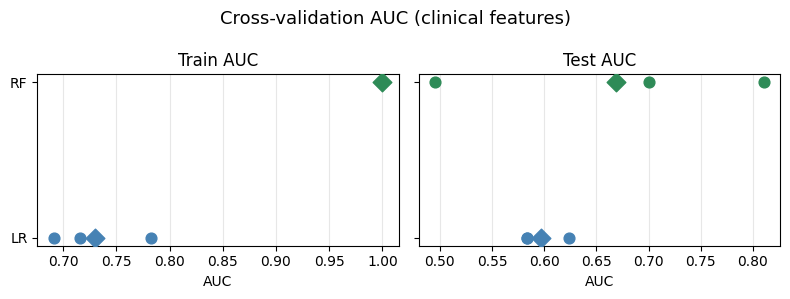

In [8]:
plot_cv_results(fold_df, title="Cross-validation AUC (clinical features)")

## With grid search

In [9]:
y_col = "OS_central_event"
X = data[list(x_columns.keys())]
y = data[y_col]

cv_results, fold_df = run_cv_experiment(
    X,
    y,
    x_columns,
    label="Clinical → OS_central_event",
    param_grids=PARAM_GRIDS,
)
print(fold_df[["model", "fold", "best_params"]].to_string(index=False))
cv_results

[Clinical → OS_central_event]  n=64  positives=27  features=11
model  fold                              best_params
   LR     1              {'C': 1.0, 'l1_ratio': 0.5}
   LR     2            {'C': 100.0, 'l1_ratio': 0.5}
   LR     3              {'C': 1.0, 'l1_ratio': 1.0}
   RF     1  {'max_depth': 5, 'min_samples_leaf': 1}
   RF     2  {'max_depth': 3, 'min_samples_leaf': 5}
   RF     3 {'max_depth': 10, 'min_samples_leaf': 1}


,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Clinical → OS_central_event,LR,0.579,0.018,0.546,0.032
1,Clinical → OS_central_event,RF,0.639,0.102,0.562,0.062


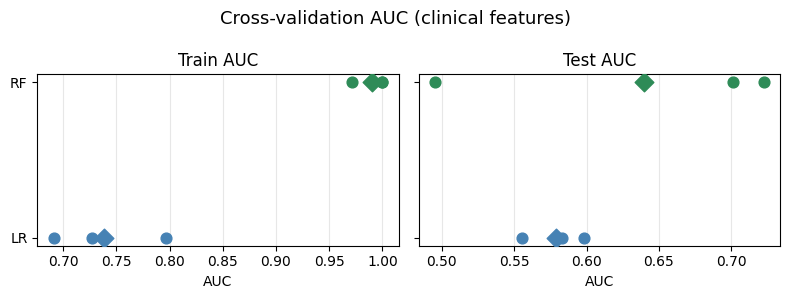

In [10]:
plot_cv_results(fold_df, title="Cross-validation AUC (clinical features)")

# Feature importance by Random Forest

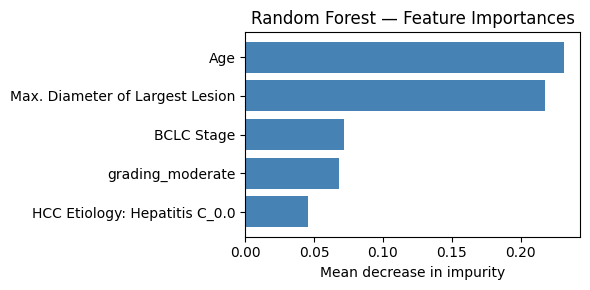

In [11]:
continuous_cols = [col for col, t in x_columns.items() if t == DataType.CONTINUOUS]
categorical_cols = [col for col, t in x_columns.items() if t == DataType.CATEGORICAL]
ordinal_cols = [col for col, t in x_columns.items() if t == DataType.ORDINAL]

mask = ~data[y_col].isna()
X_clean, y_clean = data[list(x_columns.keys())][mask], data[y_col][mask]

full_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)
full_pipe.fit(X_clean, y_clean)

ohe = (
    full_pipe.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["encoder"]
)
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
feature_names = continuous_cols + cat_feature_names + ordinal_cols

importances = full_pipe.named_steps["model"].feature_importances_
indices = np.argsort(importances)
top_indices = indices[-5:]
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(
    [feature_names[i] for i in top_indices],
    importances[top_indices],
    color="steelblue",
)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()